# Dealing with 2.5D depthmaps and cameras

This notebook shows various short experiments and snippets for dealing with 2D depth map 
data and the pinhole camera model.

The main components discussed here are the tensor subclasses:

    - `unipercept.data.tensors.DepthMap`
    - `unipercept.data.tensors.PinholeCamera`

For further reading, refer to the documentation.

## Setup and configuration

The cell below selects a dataset and samples an `unipercept.model.InputData` object from 
it. Run it before any of the other cells in the notebook.

In [1]:
%load_ext autoreload
%autoreload 2
import math
import pprint
import typing as T
import matplotlib.pyplot as plt
import functools
import itertools
import seaborn as sns
import torch
import matplotlib.pyplot as plt
from einops import reduce, rearrange
import torch
import torchvision.transforms.v2.functional as tvfn
import unipercept as up

dataset = up.data.sets.catalog.get_dataset("cityscapes-vps")(split="val", all=False)
queue, pipe = dataset()
sample = T.cast(up.model.InputData, next(iter(pipe)))

## Displaying a depth map

Depthmaps may be displayed via `up.render.draw_image_depth`.

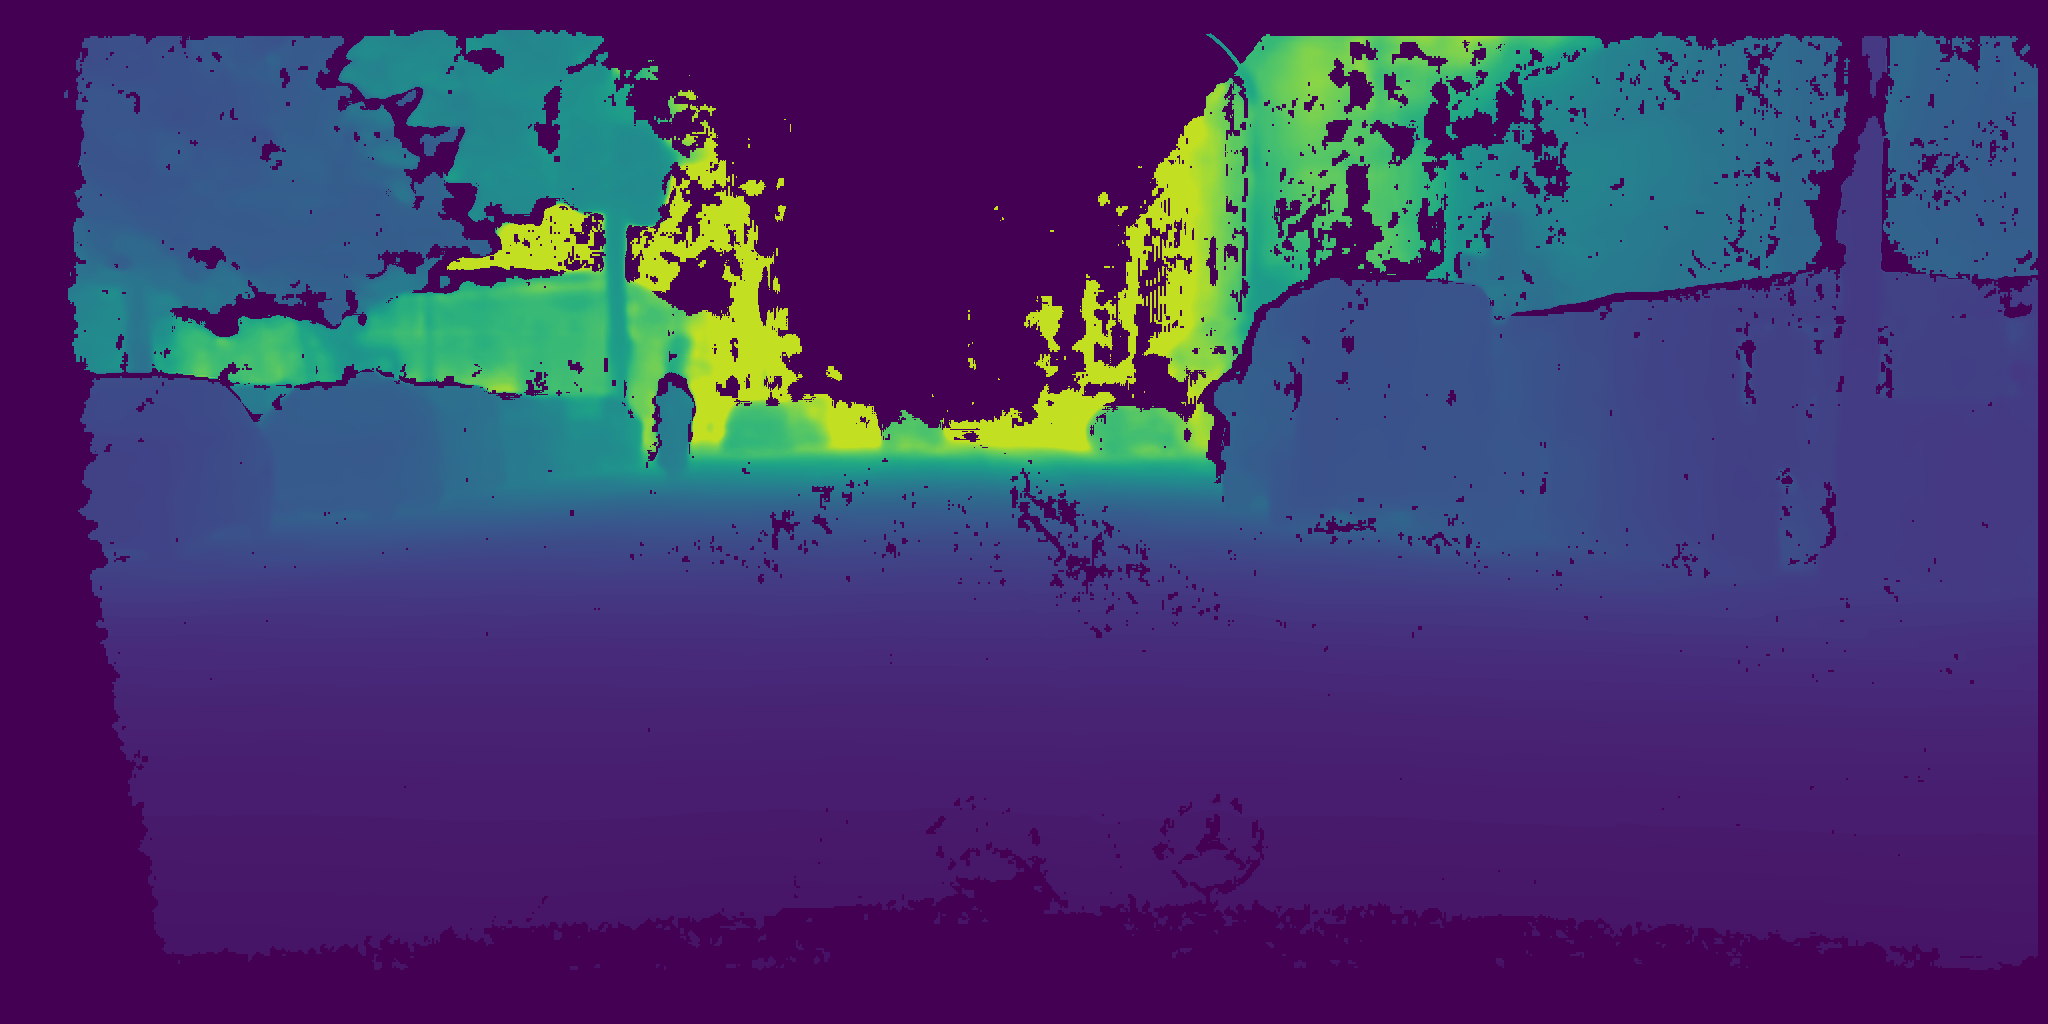

In [2]:
up.render.draw_image_depth(sample.captures.depths, info=dataset.info)

## Effects of various depth interpolation methods

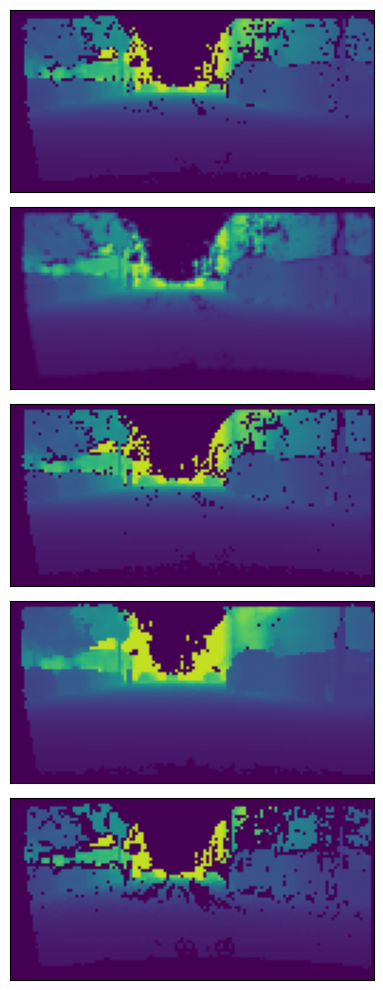

In [3]:
from torchvision.transforms.v2.functional import (
    resize_mask,
    resize_image,
    InterpolationMode,
)

dmap = sample.captures.depths


def resize_median(dmap, size):
    dmap = rearrange(
        dmap, "b (h1 h2) (w1 w2) -> b h1 w1 (h2 w2)", h1=size[0], w1=size[1]
    )
    dmap[dmap <= 0] = torch.nan
    dmap = torch.nanmedian(dmap, dim=-1).values
    dmap[~torch.isfinite(dmap)] = 0

    return dmap


def resize_mode(dmap, size):
    dmap = rearrange(
        dmap, "b (h1 h2) (w1 w2) -> b h1 w1 (h2 w2)", h1=size[0], w1=size[1]
    )
    return torch.mode(dmap, dim=-1).values


size_out = [n := 64, n * 2]


fig, axs = plt.subplots(5, 1, figsize=(20, 10))
axs_iter = iter(axs)
up.render.draw_image_depth(
    resize_mask(
        dmap,
        size_out,
    ),
    ax=next(axs_iter),
    info=dataset.info,
)
up.render.draw_image_depth(
    resize_image(
        dmap,
        size_out,
    ),
    ax=next(axs_iter),
    info=dataset.info,
)
up.render.draw_image_depth(
    resize_image(dmap, size_out, interpolation=InterpolationMode.NEAREST_EXACT),
    ax=next(axs_iter),
    info=dataset.info,
)
up.render.draw_image_depth(
    resize_median(
        dmap,
        size_out,
    ),
    ax=next(axs_iter),
    info=dataset.info,
)
up.render.draw_image_depth(
    resize_mode(
        dmap,
        size_out,
    ),
    ax=next(axs_iter),
    info=dataset.info,
)
fig.tight_layout()

## Using cameras

In [4]:
cam = sample.cameras
print(cam)

PinholeCamera(torch.float32, shape=torch.Size([1, 4, 10]), device=cpu, requires_grad=False){
  focal_length: [[2268.360107421875, 2225.54052734375]]
  principal_point: [[1048.6400146484375, 519.2769775390625]]
  rotation: [[[0.006996888667345047, -0.9999754428863525, -0.00017495575593784451], [-0.04997777193784714, -0.00017495575593784451, -0.9987502694129944], [0.9987257719039917, 0.006996888667345047, -0.04997777193784714]]]
  translation: [[[0.006996888667345047, -0.9999754428863525, -0.00017495575593784451], [-0.04997777193784714, -0.00017495575593784451, -0.9987502694129944], [0.9987257719039917, 0.006996888667345047, -0.04997777193784714]]]
  canvas_size: [[1024.0, 2048.0]]
  canvas_center: [[1024.0, 512.0]]
}


### Applying transforms (crop, resize)

Tensor(float32, shape=(1,4), device=cpu, requires_grad=False){[[0.0, 0.0, 2048.0, 1024.0]]}
Tensor(float32, shape=(1,4), device=cpu, requires_grad=False){[[1024.0, 512.0, 3072.0, 1536.0]]}
Tensor(float32, shape=(1,2), device=cpu, requires_grad=False){[[1024.0, 2048.0]]}


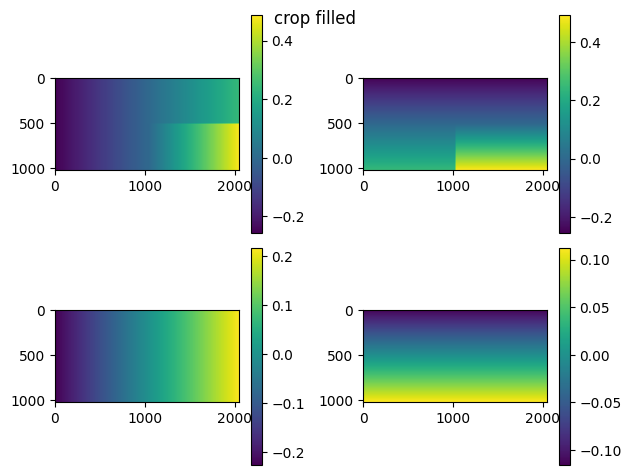

In [5]:
def plot_camera_map(cam_map):
    fig, axs = plt.subplots(2, 2, squeeze=False)
    axs = iter(axs.flatten())

    for ax, t in zip(axs, cam_map.unbind(-1), strict=True):
        im = ax.imshow(t)  # , vmin=-0.5, vmax=0.5, cmap="viridis")
        fig.colorbar(im)
    fig.tight_layout()
    return fig


print(cam.canvas_bbox)

cam_map = cam.get_fov_map([1024, 2048])[0]
# fig = plot_camera_map(cam_map)
# fig.suptitle("default")

cam_half = tvfn.crop(cam, 1024 // 2, 2048 // 2, 1024, 2048)

print(cam_half.canvas_bbox)
print(cam_half.canvas_size)

cam_map_half = cam_half.get_fov_map([512, 1024])[0]
# fig = plot_camera_map(cam_map_half)
# fig.suptitle("crop")

cam_map[512:, 1024:, :] = cam_map_half

fig = plot_camera_map(cam_map)
fig.suptitle("crop filled")
fig.show()

2D: [1024.0, 0.0] -> 3D: [-0.10862499475479126, -2.3332622051239014, 10.0] (dist: 10.269172668457031)
2D: [2048.0, 1024.0] -> 3D: [4.405649185180664, 2.267867088317871, 10.0] (dist: 11.160329818725586)
2D: [1024.0, 512.0] -> 3D: [-0.10862499475479126, -0.03269761800765991, 10.0] (dist: 10.000643730163574)
2D: [1048.6400146484375, 519.2769775390625] -> 3D: [-2.980232238769531e-07, 0.0, 10.0] (dist: 10.0)


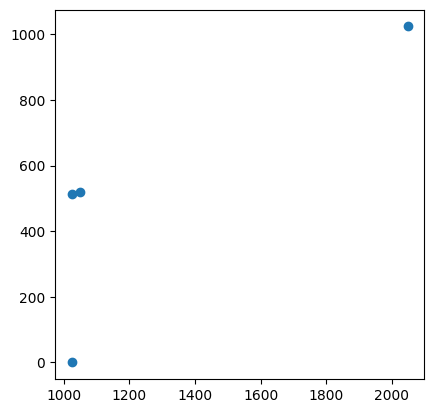

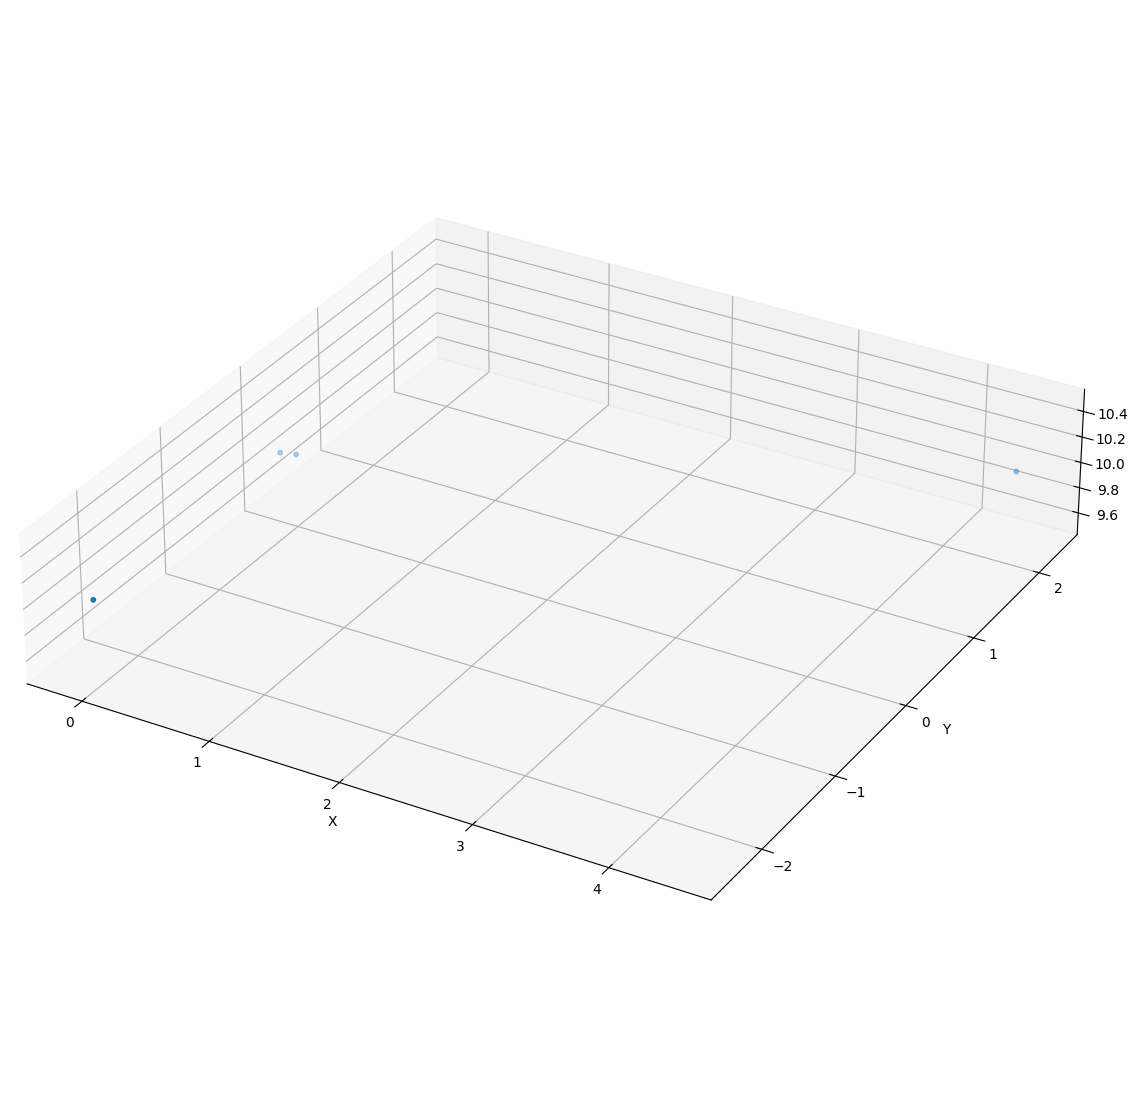

In [6]:
import numpy as np

cam = sample.cameras.clone().as_subclass(up.data.tensors.PinholeCamera)
cam.Rt.fill_(0)
cam.Rt.diagonal(0, -2, -1).fill_(1)

points_2d = torch.tensor(
    [[1024, 0], [2048, 1024], [1024, 512], cam.principal_point[0].tolist()],
    dtype=torch.float32,
)


fig, ax = plt.subplots()
ax.scatter(points_2d[:, 0], points_2d[:, 1])
ax.set_aspect("equal")
fig.show()

depths = torch.ones((points_2d.shape[0], 1)).to(cam) * 10
points_3d = cam.image_to_world(points_2d, depths)

for p2d, p3d in zip(points_2d, points_3d, strict=True):
    dist_to_origin = p3d.norm()
    print(f"2D: {p2d.tolist()} -> 3D: {p3d.tolist()} (dist: {dist_to_origin})")

fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(1, 1, 1, projection="3d")
# ax.view_init(-90,-90,0)
ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], s=10)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_aspect("equal")

fig.show()

In [7]:
import random
import torch

random.seed(0)

def sample_indices(points: torch.Tensor, n_samples: int | None = int(1e4)) -> torch.Tensor:
    if n_samples is not None:
        return random.sample(
            list(range(0, points.shape[0])), min(len(points), n_samples)
        )
    else:
        return torch.arange(0, points.shape[0], device=points.device)

def plot_pointcloud(
    dmap, image, cam, ax, n_samples: int | None=int(1e4), use_color=False, **kwargs
):
     
    kwargs.setdefault("s", 1)
    
    dmap_3d = cam.reproject_map(dmap)
    points = dmap_3d[dmap > 0]
    idx = sample_indices(points, n_samples)
    points = points[idx]
    if use_color:
        render = tvfn.pil_to_tensor(up.render.draw_image(image))
        colors = render.permute(1, 2, 0).unsqueeze(0)[dmap > 0][idx]
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=colors / 255.0, **kwargs)
    else:
        ax.scatter(points[:, 0], points[:, 1], points[:, 2], **kwargs)
    ax.set_aspect("equal")
    ax.view_init(elev=6, azim=180, roll=0)   
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    

    return points

In [8]:
from unipercept.vision.geometry import _transform_from_opencv, unsafe_inverse

print("OpenCV")
to_opencv = _transform_from_opencv("opencv")
pprint.pprint(to_opencv.tolist())
pprint.pprint(unsafe_inverse(to_opencv).tolist())

print("ISO8855")
to_iso = _transform_from_opencv("iso8855")
pprint.pprint(to_iso.tolist())
pprint.pprint(unsafe_inverse(to_iso).tolist())

print("OpenGL")
to_opengl = _transform_from_opencv("opengl")
pprint.pprint(to_opengl.tolist())
pprint.pprint(unsafe_inverse(to_opengl).tolist())


OpenCV
[[1.0, 0.0, 0.0, 0.0],
 [0.0, 1.0, 0.0, 0.0],
 [0.0, 0.0, 1.0, 0.0],
 [0.0, 0.0, 0.0, 1.0]]
[[1.0, 0.0, 0.0, 0.0],
 [0.0, 1.0, 0.0, 0.0],
 [0.0, 0.0, 1.0, 0.0],
 [0.0, 0.0, 0.0, 1.0]]
ISO8855
[[0.0, 0.0, 1.0, 0.0],
 [-1.0, 0.0, 0.0, 0.0],
 [0.0, -1.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 1.0]]
[[0.0, -1.0, 0.0, 0.0],
 [0.0, 0.0, -1.0, 0.0],
 [1.0, 0.0, 0.0, 0.0],
 [0.0, 0.0, 0.0, 1.0]]
OpenGL
[[1.0, 0.0, 0.0, 0.0],
 [0.0, -1.0, 0.0, 0.0],
 [0.0, 0.0, -1.0, 0.0],
 [0.0, 0.0, 0.0, 1.0]]
[[1.0, 0.0, 0.0, 0.0],
 [0.0, -1.0, 0.0, 0.0],
 [0.0, 0.0, -1.0, 0.0],
 [0.0, 0.0, 0.0, 1.0]]


{'convention': 'iso8855',
 'focal_length': (2268.36, 2225.5405988775956),
 'image_size': (1024, 2048),
 'principal_point': (1048.64, 519.277),
 'rotation': (0.05, 0.007, 0.0),
 'translation': (1.7, -0.1, 1.18)}


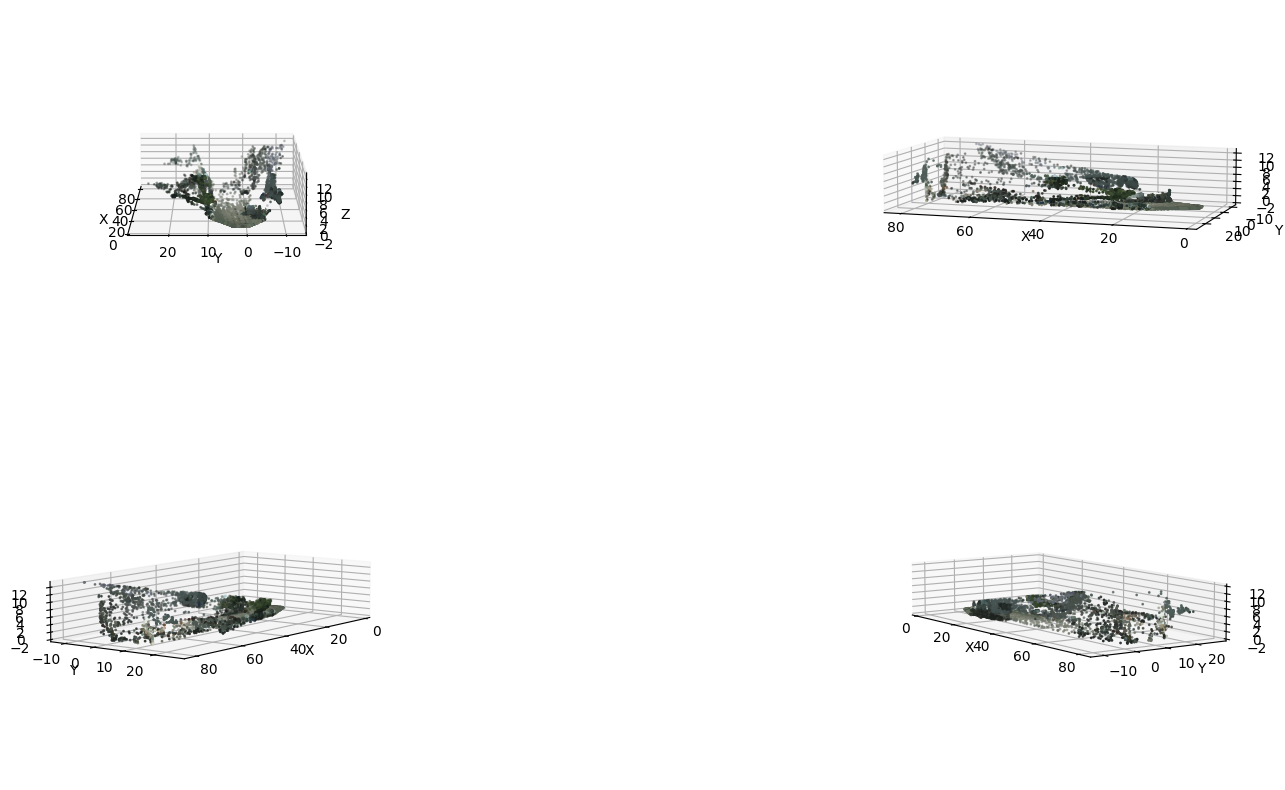

In [9]:
from unipercept.data.sets.cityscapes import CAMERA

dmap = sample.captures.depths
image = sample.captures.images
cam = sample.cameras
# cam = up.data.tensors.PinholeCamera.from_parts(cam.intrinsic_matrix, cam.extrinsic_matrix, cam.image_size)
cam_params = CAMERA.to_canonical()

pprint.pprint(cam_params)

cam = up.data.tensors.PinholeCamera.from_parameters(
    focal_length=cam_params["focal_length"],
    principal_point=cam_params["principal_point"],
    translation=cam_params["translation"],
    angles=cam_params["rotation"],
    canvas=cam_params["image_size"],
    convention="iso8855", #"opencv",
)

# dmap, image, cam = map(lambda t: tvfn.resize(t, (512, 1024)), (dmap, image, cam))
#cam.E[:] = cam.E# @ unsafe_inverse(to_iso)
cam = cam.as_subclass(up.data.tensors.PinholeCamera)

fig = plt.figure(figsize=(20, 10))

for n, azim in enumerate(torch.linspace(180, -35,4).tolist()):
    ax = fig.add_subplot(2, 2, n + 1, projection="3d")

    plot_pointcloud(dmap, image, cam, ax, use_color=True)

    ax.view_init(elev=8, azim=azim)
    #ax.set_title(f"{azim=}")
#fig.tight_layout()

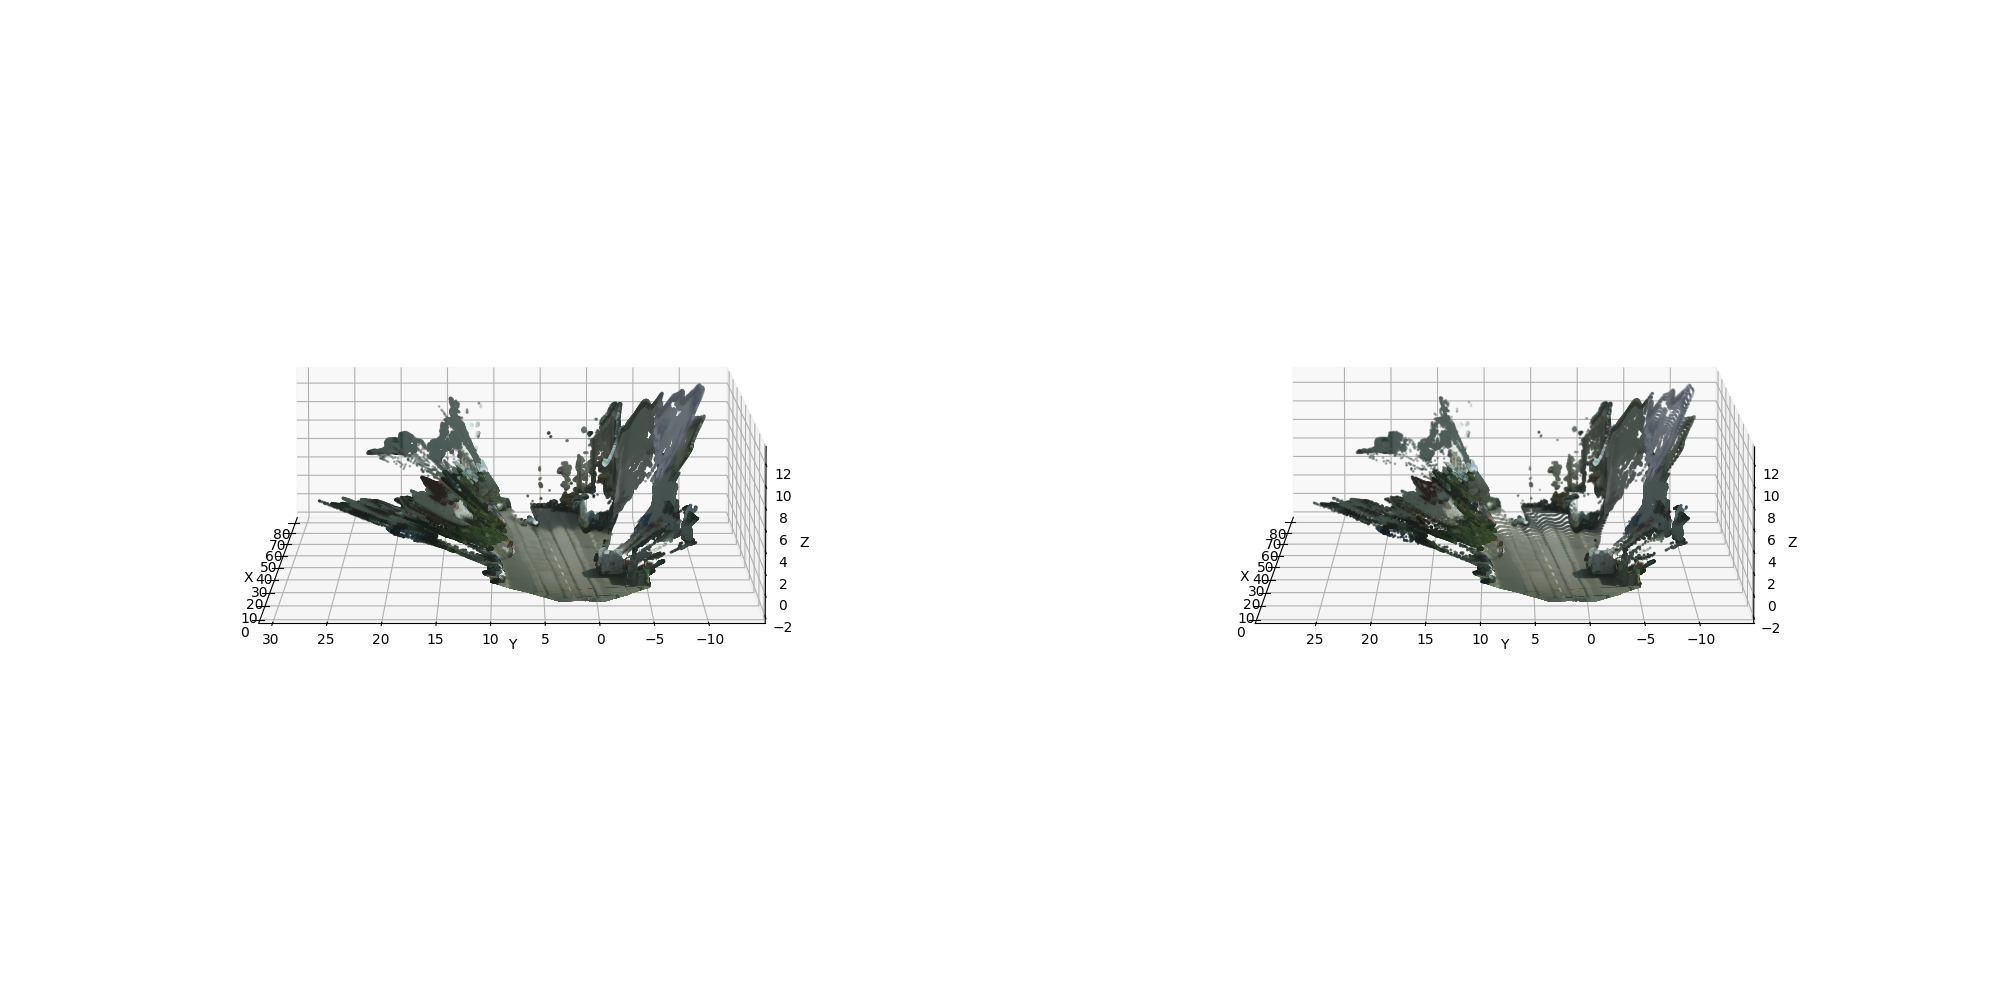

In [10]:
dmap = sample.captures.depths
image = sample.captures.images
cam = sample.cameras

fig = plt.figure(figsize=(20, 20))


# Point cloud 1 (without resize)
ax = fig.add_subplot(1, 2, 1, projection="3d")
plot_pointcloud(dmap, image, cam, ax, use_color=True, n_samples=None)

# Point cloud 2 (with resize)
dmap, image, cam = map(lambda t: tvfn.resize(t, (512, 1024)), (dmap, image, cam))
cam = cam.as_subclass(up.data.tensors.PinholeCamera)
ax = fig.add_subplot(1, 2, 2, projection="3d")
plot_pointcloud(dmap, image, cam, ax, use_color=True, n_samples=None)

fig.tight_layout()
pass

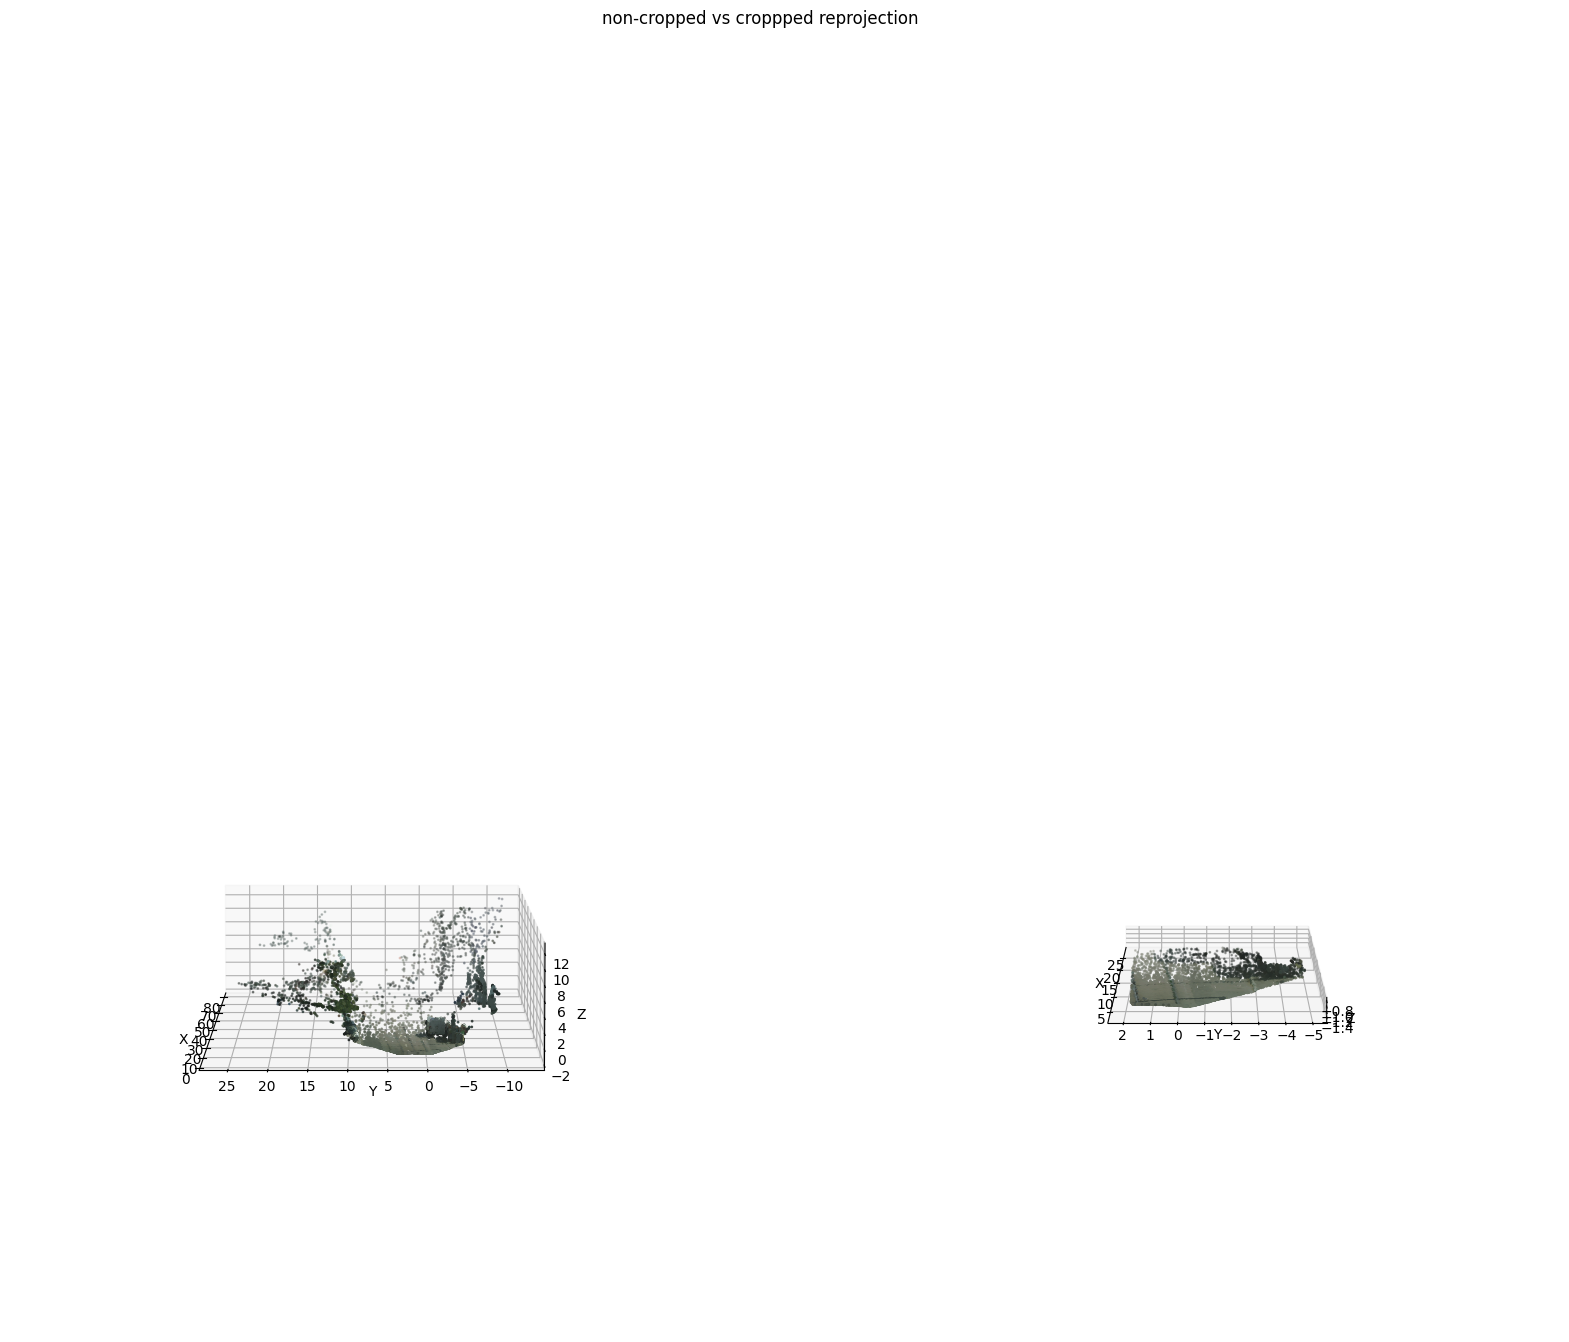

In [11]:
# Crop
dmap = sample.captures.depths
image = sample.captures.images
cam = sample.cameras

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(1, 2, 1, projection="3d")
plot_pointcloud(dmap, image, cam, ax, use_color=True)

dmap, image, cam = map(lambda t: tvfn.crop(t, 512, 1024, 512, 1024), (dmap, image, cam))
cam = cam.as_subclass(up.data.tensors.PinholeCamera)
ax = fig.add_subplot(1, 2, 2, projection="3d")
plot_pointcloud(dmap, image, cam, ax, use_color=True)
fig.suptitle("non-cropped vs croppped reprojection")
fig.show()

In [ ]:
import open3d as o3d
from open3d.web_visualizer import draw

# Depthmap, image and camera params
dmap = sample.captures.depths
image = sample.captures.images
cam = sample.cameras

# Apply projection
dmap_3d = cam.reproject_map(dmap)
points = dmap_3d[dmap > 0]
render = tvfn.pil_to_tensor(up.render.draw_image(image))
colors = render.permute(1, 2, 0).unsqueeze(0)[dmap > 0]

# Sample 
idx = sample_indices(points, 100)
points = points[idx]
colors = colors[idx]

# Create Open3D PointCloud object
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Visualize interactively
draw(pcd)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.
